# OpenScope's Psycode Dataset

This notebook explores the "PsyCode" dataset, an OpenScope project designed to investigate the effects of psilocybin on visual processing and behavior in the mouse visual cortex. The core experimental design follows a 'pre-drug / post-drug' structure, allowing for a within-subject comparison of neural activity and task performance. Initially, mice are trained on a visual change detection task, similar to the paradigm used in the Visual Behavior Optical Physiology and Visual Behavior Neuropixels projects. In this go/no-go task, mice are shown a continuous series of briefly presented natural images (presented for 250 ms), and they earn water rewards by correctly reporting when the identity of the image changes. Alongside this behavior, the experiment includes a battery of passive visual stimulation protocols to probe the functional properties of visual neurons.

The experimental timeline follows a structured sequence. Before psilocybin application, mice first undergo passive visual stimulation for receptive field (RF) mapping and a surround suppression paradigm, providing a baseline measurement of each neuron's tuning properties. This is followed by the change detection task to end the pre-injection epoch. After psilocybin is administered, the same sequence of stimuli is presented in reverse: first the change detection task, followed by receptive field mapping and surround suppression. Finally, passive visual stimulation is repeated, now including an optotagging protocol at the end to identify cortical SST neurons. This symmetrical design—with both behavioral and passive protocols repeated before and after drug administration—enables a powerful within-subject analysis of how psilocybin modulates visual processing, from basic receptive field properties to complex task-dependent dynamics involving natural image perception. The dataset therefore offers a unique opportunity to link molecularly-specific cell types, natural image perception, and the state-dependent changes induced by a psychedelic compound.

### Session structure

![image.png](../../data/images/psycode_embedded/session_timeline.png)

### Change detection task

![image.png](../../data/images/psycode_embedded/psycode_change_detection.png)

### Environment Setup
⚠️**Note: If running on a new environment, run this cell once and then restart the kernel**⚠️

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .
    %cd docs/projects

In [2]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from math import floor, ceil, isclose
from PIL import Image
from collections import Counter

### The Experiment
As shown in the metadata table below, Openscope's Psycode Experiment has produced 20 main files on the [DANDI Archive](http://dandiarchive.org), with 6 males and 14 females which all have Sst genotypes. This table was generated from [Getting Experimental Metadata from DANDI](../basics/get_dandiset_metadata.ipynb).

In [3]:
session_files = pd.read_csv("../../data/psycode_sessions.csv")
session_files

,Unnamed: 0,identifier,size,path,session_time,sub_name,session_id,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
0,0,460eb1a0-9707-4a24-970d-e41a6c1d8792,16765763553,sub-767932/sub-767932_ses-ecephys-767932-2025-...,2025-03-26 14:07:06-07:00,767932,ecephys_767932_2025-03-26_14-07-06,F,P185D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",3443,7324.32257
1,1,5de7caf3-111f-4155-9f70-6b570e884883,17526605372,sub-767932/sub-767932_ses-ecephys-767932-2025-...,2025-03-25 14:35:45-07:00,767932,ecephys_767932_2025-03-25_14-35-45,F,P184D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",3913,7316.97920
2,2,94742fda-d92e-4847-8c61-463115a0bde6,17272136529,sub-753316/sub-753316_ses-ecephys-753316-2025-...,2025-01-29 13:57:16-08:00,753316,ecephys_753316_2025-01-29_13-57-16,F,P202D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",3854,7319.29586
3,3,3b7e99ce-184c-4b1b-aff0-4ecd76757fc8,18491019021,sub-760322/sub-760322_ses-ecephys-760322-2025-...,2025-02-06 14:07:25-08:00,760322,ecephys_760322_2025-02-06_14-07-25,F,P176D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",4743,7313.39442
4,4,d55671d7-de8b-4873-8b30-9fadc1a4bf43,17661675315,sub-767925/sub-767925_ses-ecephys-767925-2025-...,2025-02-13 11:40:19-08:00,767925,ecephys_767925_2025-02-13_11-40-19,M,P144D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",3932,7323.10842
5,5,f5850f67-1961-4f66-a476-0389b7ff127d,18238462077,sub-760324/sub-760324_ses-ecephys-760324-2025-...,2025-02-20 11:31:01-08:00,760324,ecephys_760324_2025-02-20_11-31-01,F,P190D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",4471,7319.64269
6,6,2981ef2f-55e0-4cc7-a920-a2d1dc591357,17752907004,sub-767926/sub-767926_ses-ecephys-767926-2025-...,2025-02-27 15:12:01-08:00,767926,ecephys_767926_2025-02-27_15-12-01,M,P158D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",4086,7323.49644
7,7,4f7f4edf-19e7-405a-9052-94be8b50a7b3,18935765451,sub-760322/sub-760322_ses-ecephys-760322-2025-...,2025-02-05 14:30:46-08:00,760322,ecephys_760322_2025-02-05_14-30-46,F,P175D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",5057,7321.59033
8,8,4b006de0-a806-48f0-bd60-6725da547e3d,18616606786,sub-760324/sub-760324_ses-ecephys-760324-2025-...,2025-02-19 10:56:40-08:00,760324,ecephys_760324_2025-02-19_10-56-40,F,P189D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",4626,7322.07561
9,9,8bf19ba7-725c-430e-8f82-b3da1acb4e10,18965757347,sub-767926/sub-767926_ses-ecephys-767926-2025-...,2025-02-26 15:49:35-08:00,767926,ecephys_767926_2025-02-26_15-49-35,M,P157D,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,"{'ProbeC', 'ProbeE', 'ProbeD', 'ProbeF', 'Devi...","{'5 hz pulse train_presentations', 'behavior_p...",4712,7324.71362


In [4]:
m_count = len(session_files["sub_sex"][session_files["sub_sex"] == "M"])
f_count = len(session_files["sub_sex"][session_files["sub_sex"] == "F"])
sst_count = len(session_files[session_files["sub_genotype"].str.count("Sst") >= 1])
pval_count = len(session_files[session_files["sub_genotype"].str.count("Pval") >= 1])
wt_count = len(session_files[session_files["sub_genotype"].str.count("wt/wt") >= 1])

print("Dandiset Overview:")
print(len(session_files), "files")
print(len(set(session_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")

Dandiset Overview:
20 files
10 subjects 6 males, 14 females
20 sst, 0 pval, 0 wt


### Downloading Ecephys Files

In [5]:
dandiset_id = "001417"
dandi_filepath_saline = "sub-753316/sub-753316_ses-ecephys-753316-2025-01-28-13-57-06_ecephys.nwb"
dandi_filepath_psilo = "sub-753316/sub-753316_ses-ecephys-753316-2025-01-29-13-57-16_ecephys.nwb"
download_loc = "."
dandi_api_key = os.environ["DANDI_API_KEY"]

In [6]:
# This can sometimes take a while depending on the size of the file
io_saline = dandi_download_open(dandiset_id, dandi_filepath_saline, download_loc, dandi_api_key=dandi_api_key)
nwb_saline = io_saline.read()

io_psilo = dandi_download_open(dandiset_id, dandi_filepath_psilo, download_loc, dandi_api_key=dandi_api_key)
nwb_psilo = io_psilo.read()

File already exists
Opening file
File already exists
Opening file


### Showing Probe Tracks
The images below were rendered using the [Visualizing Neuropixels Probe Locations](../visualization/visualize_neuropixels_probes.ipynb) notebook. The probes are using the [Common Coordinate Framework](https://community.brain-map.org/t/allen-mouse-ccf-accessing-and-using-related-data-and-tools/359) (CCF). The experiment uses six probes labeled A-F to target various regions.

teal = saline

salmon = psilocybin

(-0.5, 1166.5, 805.5, -0.5)

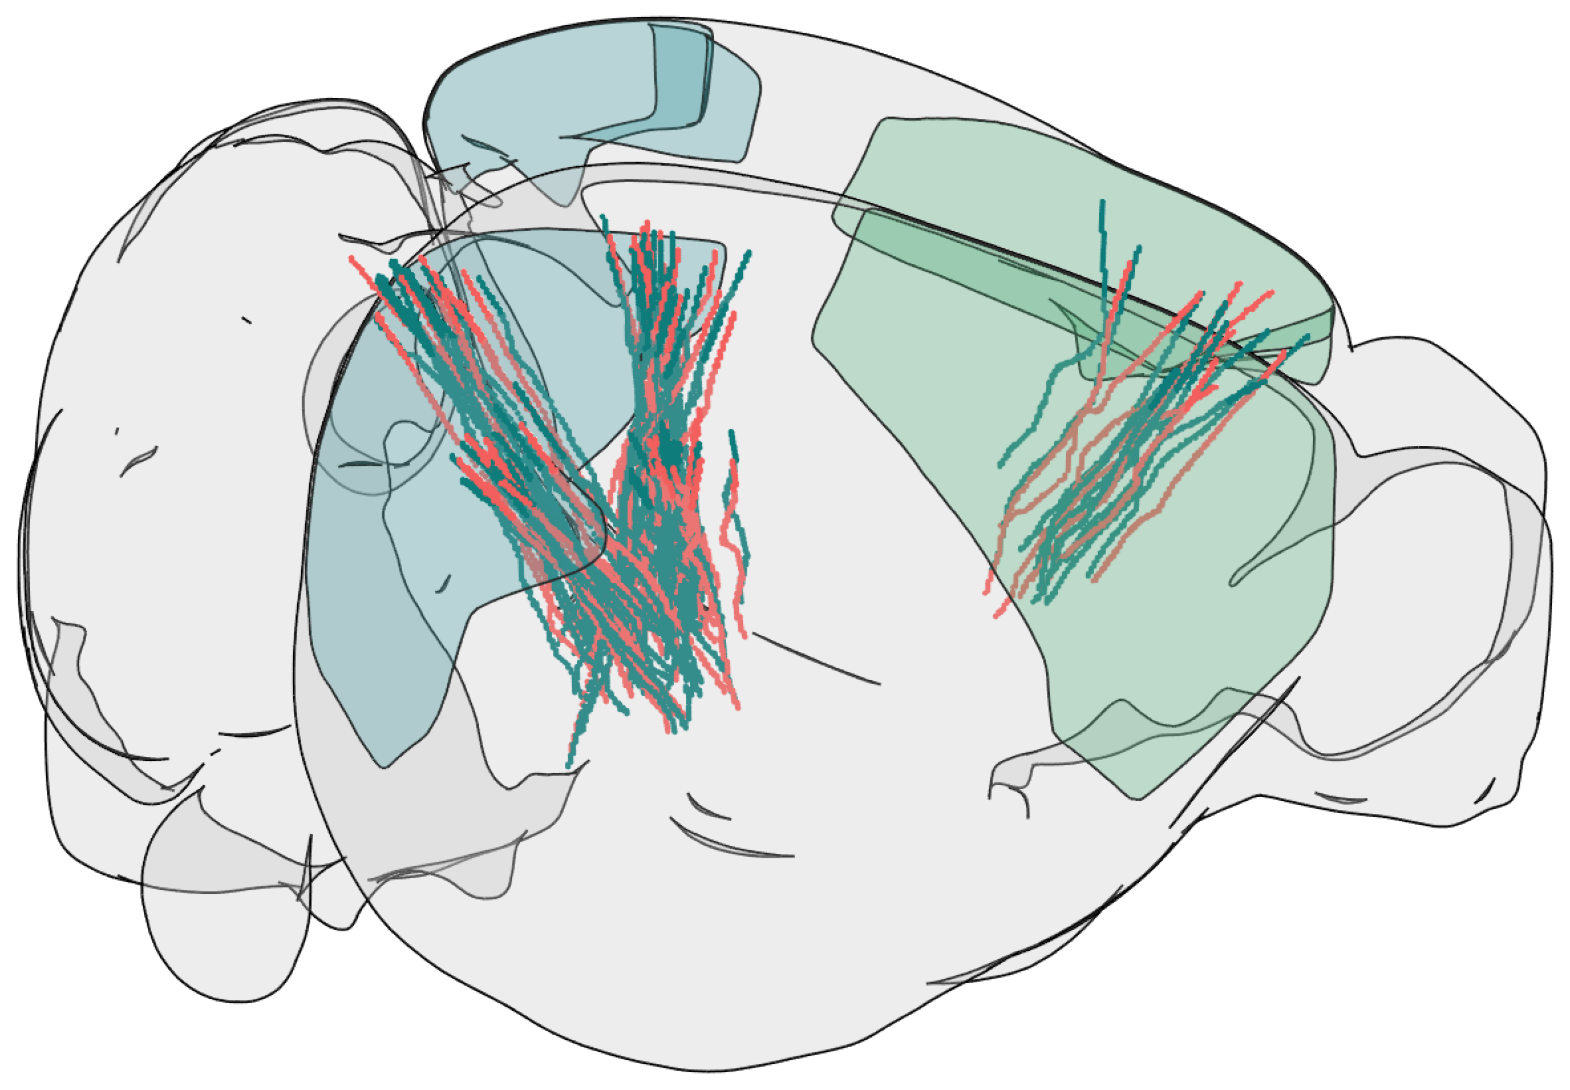

In [7]:
all_probes = Image.open("../../data/images/psycode_all_probes.png")

fig, ax = plt.subplots(1,1,figsize=(20,60))

ax.imshow(all_probes)

# for ax in axes:
ax.axis("off")

### Extracting Units Spikes
Below, the `Units` table is retrieved from the file. It contains many metrics for every putative neuronal unit, printed below. For the analysis in this notebook, we are only interested in the `spike_times` attribute. This is an array of timestamps that a spike is measured for each unit. For more information on the various unit metrics, see [Visualizing Unit Quality Metrics](../visualization/visualize_unit_metrics.ipynb).

In [8]:
units_saline = nwb_saline.units.to_dataframe()
units_saline[:10]

,spike_times,electrodes,waveform_mean,waveform_sd,unit_name,exp_decay,device_name,nn_hit_rate,depth,amplitude,...,ks_unit_id,estimated_x,drift_ptp,l_ratio,amplitude_cv_range,firing_rate,sync_spike_4,drift_mad,amplitude_cutoff,velocity_above
id,,,,,,,,,,,,,,,,,,,,,
0,"[24.254828959684225, 28.56911275642596, 36.389...",location ...,"[[-0.6786001324653625, -0.8564395904541016, -0...","[[16.961021423339844, 17.432619094848633, 17.1...",bb52adf6-b908-4bdf-8dfc-d68072c088eb,0.070916,ProbeA,0.230469,59.15,81.73,...,0,3.79,4.164932,0.328409,NaN,5.864713,0.000793,0.460940,0.000204,NaN
1,"[2797.073748351054, 2797.264680967297, 2797.30...",location ...,"[[-1.661401391029358, -1.2168009281158447, -0....","[[21.353561401367188, 24.988924026489258, 17.5...",e8e5231b-fc3a-423a-a0c6-b1a4633951c1,0.025485,ProbeA,0.959635,42.77,326.36,...,1,0.33,NaN,0.002154,NaN,0.370570,0.000738,NaN,0.000459,NaN
2,"[39.21427277614529, 39.44813856447665, 45.5282...",location ...,"[[-1.5912011861801147, -1.0951205492019653, -1...","[[17.77315902709961, 19.262195587158203, 18.13...",b453c3ec-0e19-4bed-83a4-e3901c486158,0.017647,ProbeA,0.453333,19.08,120.50,...,2,54.12,5.990026,0.383660,NaN,3.592614,0.001028,0.332858,0.000141,NaN
3,"[24.25489562610051, 27.72414926320878, 28.5692...",location ...,"[[-1.3899598121643066, -2.335320234298706, -2....","[[19.17218017578125, 21.91944694519043, 16.453...",263d4288-03f7-468d-87e6-8f932f3e60b2,0.028515,ProbeA,0.851598,28.78,358.12,...,3,5.93,NaN,0.162596,NaN,0.133323,0.001026,NaN,0.006551,NaN
4,"[20.502176386944075, 22.088603762094387, 22.11...",location ...,"[[-0.6130804419517517, 0.8096398115158081, -0....","[[13.425420761108398, 15.351962089538574, 15.3...",3288e605-d6fb-4da2-8bba-976c90065590,0.027983,ProbeA,0.452222,-3.58,106.37,...,4,35.46,NaN,2.151348,1.037750,1.392304,0.003241,NaN,0.001459,NaN
5,"[1308.6085386152433, 1333.9201102186387, 1392....",location ...,"[[-0.8049142956733704, 0.8164132833480835, -1....","[[17.11772918701172, 20.254188537597656, 15.07...",22d32b90-2188-4390-a1c5-7d71bf075989,0.029629,ProbeA,0.635724,34.00,322.87,...,5,3.69,NaN,0.156626,NaN,0.055654,0.000000,NaN,NaN,NaN
6,"[2805.3872837943777, 2805.4413169247778, 2805....",location ...,"[[-0.6598799824714661, 0.4679998457431793, 0.0...","[[18.709257125854492, 18.72583770751953, 17.29...",2c6fd919-7f85-4e6c-b405-b8d2672e3a2f,NaN,ProbeA,0.837240,80.18,182.32,...,6,20.12,NaN,0.022394,NaN,0.242580,0.001127,NaN,0.002586,632.246536
7,"[28.092014548275046, 36.78661522708982, 36.948...",location ...,"[[-3.116880178451538, -1.895399570465088, -1.9...","[[21.290372848510742, 22.783222198486328, 23.8...",d08c8379-41c2-4395-990d-c6bf2d53ceb8,0.034820,ProbeA,0.924444,4.33,303.72,...,7,21.27,NaN,0.001605,NaN,0.124572,0.000000,NaN,0.001914,482.258327
8,"[21.827338076669466, 23.11983322241471, 24.028...",location ...,"[[-2.045161247253418, -1.1278799772262573, -1....","[[13.081856727600098, 14.002058982849121, 13.0...",979520c9-8daf-4d75-831e-f4eb8cbee593,0.035066,ProbeA,0.611111,-0.40,134.03,...,8,25.14,NaN,0.747981,1.612507,0.664838,0.002057,NaN,0.001777,NaN


In [9]:
def get_unit_location(unit_row):
    mean_waveforms = unit_row['waveform_mean']
    waveform_mins = np.min(mean_waveforms, axis=0)
    peak_channel_idx = np.argmin(waveform_mins)
    detected_electrodes = unit_row['electrodes']
    unit_location = detected_electrodes.iloc[peak_channel_idx].location
    return unit_location

print(set(get_unit_location(row) for _, row in units_saline.iterrows()))

{'VISp6a', 'LSc', 'POST', 'fp', 'MOs1', 'VISp1', 'LGd-sh', 'LGv', 'ACAv2/3', 'VISp2/3', 'root', 'VPM', 'ACAd2/3', 'VISal1', 'PP', 'VISa6a', 'DG-po', 'LT', 'SSp-bfd2/3', 'SSp-bfd6a', 'DG-sg', 'SSp-bfd4', 'VISp5', 'ACAv5', 'PIL', 'CA2', 'SSp-bfd1', 'fiber tracts', 'VISp6b', 'VISam6b', 'VISal6b', 'ccs', 'ccb', 'ACAv1', 'VISrl6a', 'SUB', 'VISp4', 'MOs2/3', 'LGd-co', 'void', 'CA1', 'VISal2/3', 'VISal6a', 'ACAd5', 'VISrl5', 'bsc', 'DG-mo', 'VISal4', 'VISa2/3', 'LSr', 'VISam5', 'MGm', 'or', 'alv', 'VISam2/3', 'VISam4', 'VISa6b', 'CA3', 'MGd', 'MGv', 'MOs5', 'TH', 'dhc', 'VISal5', 'SSp-bfd5', 'VISam6a', 'VISa1'}


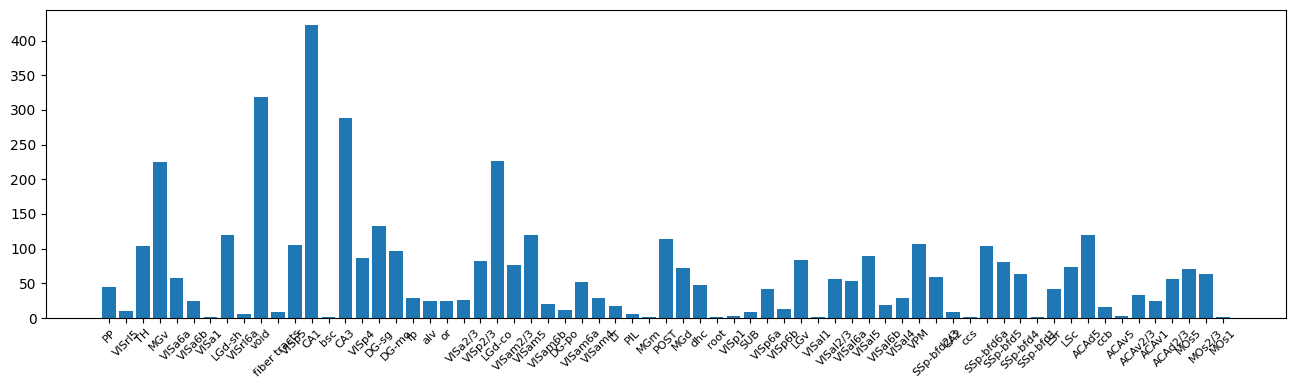

In [10]:
locations = [get_unit_location(row) for _, row in units_saline.iterrows()]
counts = Counter(locations)

fig, ax = plt.subplots(figsize=(16,4))
ax.bar(counts.keys(), counts.values())

ax.tick_params(axis='x', labelrotation=45, labelsize=8)


### let s focus on primary visual cortex to see responses to a single natural image

In [ ]:
### you can uncommnet and check responses in other areas

brain_regions = [
    # --- LGd (Lateral Geniculate Nucleus) ---
    #'LGd-co', 'LGd-sh', 'LGv',
    
    # --- ACA (Anterior Cingulate) ---
    #'ACAd2/3', 'ACAv2/3', 'ACAv5',
    
    # --- VISp (Primary Visual) - Ordered 1→6 ---
    'VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b',
    
    # --- VISal (Anterolateral) ---
    #'VISal2/3', 'VISal4', 'VISal5', 'VISal6a', 'VISal6b',
    
    # --- VISam (Anteromedial) ---
    'VISam2/3', 'VISam4', 'VISam5', 'VISam6a', 'VISam6b',
    
    # --- VISa (Auditory-visual? / Anterior) ---
    #'VISa2/3', 'VISa6a', 'VISa6b',
    
    # --- VISrl (Rostrolateral) ---
    #'VISrl5', 'VISrl6a',
]

# select units based if they have 'good' quality and exists in one of the specified brain_regions
def select_units(units):
    units_spike_times = []
    location_units_spike_times = []
    for location in brain_regions:
        for _, row in units.query('(firing_range > 8) & (decoder_label== "sua") & (presence_ratio >.95)').iterrows():
            if get_unit_location(row) == location:
                location_units_spike_times.append(row.spike_times)
    units_spike_times += location_units_spike_times
    return units_spike_times

units_spike_times_saline = select_units(units_saline)
print(f"Selected {len(units_spike_times_saline)} units")

Selected 89 units


### Session Timeline
To get a good idea of the order and the way stimulus is shown throughout the session, the code below generates a timeline of the various 'epochs' of stimulus. It can be seen that there are many repeated epochs of the gratings presentation, interspersed with intermission presentations, followed by an epoch of receptive field presentations.

In [12]:
nwb_saline.intervals['behavior_presentations']

,start_time,stop_time,duration,image_index,image_name,image_set,omitted,stim_name,timeseries
id,,,,,,,,,
0,1440.39521,1440.64542,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2694, 1, timestamps pynwb.base.TimeSeries at 0x2130140930848\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (14085,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (14085,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
1,1441.14580,1441.39601,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2695, 1, timestamps pynwb.base.TimeSeries at 0x2130140930848\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (14085,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (14085,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
2,1441.89643,1442.14664,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2696, 1, timestamps pynwb.base.TimeSeries at 0x2130140930848\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (14085,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (14085,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"
3,1442.64706,1442.89726,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2697, 1, timestamps pynwb.base.TimeSeries at 0x2130140930848\nFields:\n comments: no comments\n conversion: 1.0\n data: <HDF5 dataset ""data"": shape (14085,), type ""<f8"">\n description: no description\n interval: 1\n offset: 0.0\n resolution: -1.0\n timestamps: <HDF5 dataset ""timestamps"": shape (14085,), type ""<f8"">\n timestamps_unit: seconds\n unit: s\n)]"


In [13]:
injection_time = nwb_saline.intervals["injection_times"].to_dataframe()["start_time"].iloc[0]
print("Injection time:", injection_time)


Injection time: 2881.3192


In [14]:
# extract epoch times from stim table where stimulus rows have a different 'block' than following row
# returns list of epochs, where an epoch is of the form (stimulus name, stimulus block, start time, stop time)
def extract_epochs(stim_name, stim_table, epochs):
    
    # specify a current epoch stop and start time
    epoch_start = stim_table.start_time[0]
    epoch_stop = stim_table.stop_time[0]

    # for each row, try to extend current epoch stop_time
    for i in range(len(stim_table)):
        this_block = stim_table.stim_name[i]
        # if end of table, end the current epoch
        if i+1 >= len(stim_table):
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            break
            
        next_block = stim_table.stim_name[i+1]
        # if next row is the same stim block, push back epoch_stop time
        if next_block == this_block:
            epoch_stop = stim_table.stop_time[i+1]
        # otherwise, end the current epoch, start new epoch
        else:
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            epoch_start = stim_table.start_time[i+1]
            epoch_stop = stim_table.stop_time[i+1]
    
    return epochs

In [15]:
# extract epochs from all valid stimulus tables
epochs = []
for stim_name in nwb_saline.intervals.keys():
    stim_table = nwb_saline.intervals[stim_name]
    try:
        epochs = extract_epochs(stim_name, stim_table, epochs)
    except:
        continue

# epochs take the form (stimulus name, stimulus block, start time, stop time)
print(len(epochs))
epochs.sort(key=lambda x: x[2])
for epoch in epochs:
    print(epoch)

9
('pre_receptive_field_mapping_presentations', 'pre_receptive_field_mapping', 44.391760000000005, 530.8161600000001)
('spontaneous_presentations', 'spontaneous', 530.8161600000001, 6436.58232)
('pre_surround_suppression_mapping_presentations', 'pre_surround_suppression_mapping', 985.78085, 1435.8580399999998)
('behavior_presentations', 'behavior', 1440.39521, 5040.26209)
('post_receptive_field_mapping_presentations', 'post_receptive_field_mapping', 5045.41641, 5531.82405)
('post_surround_suppression_mapping_presentations', 'post_surround_suppression_mapping', 5986.78866, 6436.88252)
('40 hz pulse train_presentations', '40 hz pulse train', 6452.19863, 6653.49075)
('raised_cosine_presentations', 'raised_cosine', 6454.01119, 6667.37102)
('5 hz pulse train_presentations', '5 hz pulse train', 6455.88564, 6651.78086)


In [16]:
time_start = floor(min([epoch[2] for epoch in epochs]))
time_end = ceil(max([epoch[3] for epoch in epochs]))
all_units_spike_times_saline = np.concatenate(units_spike_times_saline).ravel()
print(time_start, time_end)

# make histogram of unit spikes per second over specified timeframe
time_bin_edges = np.linspace(time_start, time_end, (time_end-time_start))
hist, bins = np.histogram(all_units_spike_times_saline, bins=time_bin_edges)

44 6668


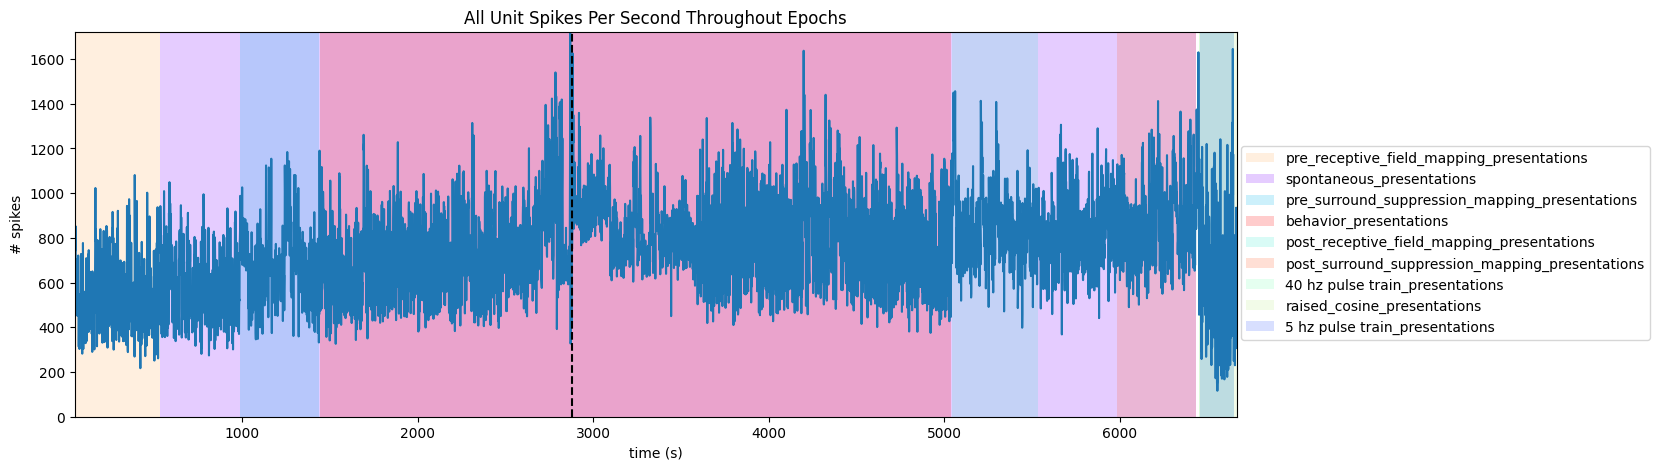

In [17]:
# generate plot of spike histogram with colored epoch intervals and legend
fig, ax = plt.subplots(figsize=(15,5))

# assign unique color to each stimulus name
stim_names = list({epoch[0] for epoch in epochs})
colors = plt.cm.rainbow(np.linspace(0,1,len(stim_names)))
stim_color_map = {stim_names[i]:colors[i] for i in range(len(stim_names))}

epoch_key = {}
height = max(hist)
# draw colored rectangles for each epoch
for epoch in epochs:
    stim_name, stim_block, epoch_start, epoch_end = epoch
    color = stim_color_map[stim_name]
    rec = ax.add_patch(mpl.patches.Rectangle((epoch_start, 0), epoch_end-epoch_start, height, alpha=0.2, facecolor=color))
    epoch_key[stim_name] = rec

ax.set_xlim(time_start, time_end)
ax.set_ylim(-0.1, height+0.1)
ax.set_xlabel("time (s)")
ax.set_ylabel("# spikes")
ax.set_title("All Unit Spikes Per Second Throughout Epochs")

fig.legend(epoch_key.values(), epoch_key.keys(), loc="lower right", bbox_to_anchor=(1.18, 0.25))
ax.plot(bins[:-1], hist)

ax.axvline(injection_time, color="k", linestyle="--")

### Extracting Stimulus Times

In [18]:
nwb_saline.intervals.keys()

dict_keys(['40 hz pulse train_presentations', '5 hz pulse train_presentations', 'behavior_presentations', 'injection_times', 'post_receptive_field_mapping_presentations', 'post_surround_suppression_mapping_presentations', 'pre_receptive_field_mapping_presentations', 'pre_surround_suppression_mapping_presentations', 'raised_cosine_presentations', 'spontaneous_presentations'])

In [19]:
stim_table_saline = nwb_saline.intervals["behavior_presentations"]
print(np.mean(np.diff(stim_table_saline.start_time)))
print(set(stim_table_saline.image_name))

1.0007274589936057
{'im047_r', 'im036_r', 'im012_r', 'im083_r', 'im044_r', 'im115_r', 'im078_r', 'im111_r'}


In [20]:
stim_table_saline[:10]

,start_time,stop_time,duration,image_index,image_name,image_set,omitted,stim_name,timeseries
id,,,,,,,,,
0,1440.39521,1440.64542,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2694, 1, timestamps pynwb.base.TimeSeries at..."
1,1441.14580,1441.39601,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2695, 1, timestamps pynwb.base.TimeSeries at..."
2,1441.89643,1442.14664,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2696, 1, timestamps pynwb.base.TimeSeries at..."
3,1442.64706,1442.89726,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2697, 1, timestamps pynwb.base.TimeSeries at..."
4,1443.39769,1443.64790,0.2502099999999245,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2698, 1, timestamps pynwb.base.TimeSeries at..."
5,1444.14832,1444.39852,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2699, 1, timestamps pynwb.base.TimeSeries at..."
6,1444.89895,1445.14915,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2700, 1, timestamps pynwb.base.TimeSeries at..."
7,1445.64958,1445.89978,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2701, 1, timestamps pynwb.base.TimeSeries at..."
8,1446.40021,1446.65041,0.2501999999999498,0.0,im036_r,Natural_Images_Lum_Matched_set_ophys_G_2019.05.26,False,behavior,"[(2702, 1, timestamps pynwb.base.TimeSeries at..."


In [21]:
# select times where im036_r was displayed
selected_stim_times_saline = [stim_table_saline[i].start_time.item() for i in range(len(stim_table_saline)) if stim_table_saline.image_name[i] == "im036_r"]
print(f"Selected {len(selected_stim_times_saline)} stimulus trials")

Selected 430 stimulus trials


### Generating Spike Matrix

In [22]:
# bin size for counting spikes
time_resolution = 0.005

# start and end times (relative to the stimulus at 0 seconds) that we want to examine and align spikes to
window_start_time = -0.25
window_end_time = 0.5

In [23]:
def get_spike_matrix(stim_times, units_spike_times, bin_edges):
    time_resolution = np.mean(np.diff(bin_edges))
    # 3D spike matrix to be populated with spike counts
    spike_matrix = np.zeros((len(units_spike_times), len(stim_times), len(bin_edges)-1))

    # populate 3D spike matrix for each unit for each stimulus trial by counting spikes into bins
    for unit_idx in range(len(units_spike_times)):
        spike_times = units_spike_times[unit_idx]

        for stim_idx, stim_time in enumerate(stim_times):
            # get spike times that fall within the bin's time range relative to the stim time        
            first_bin_time = stim_time + bin_edges[0]
            last_bin_time = stim_time + bin_edges[-1]
            first_spike_in_range, last_spike_in_range = np.searchsorted(spike_times, [first_bin_time, last_bin_time])
            spike_times_in_range = spike_times[first_spike_in_range:last_spike_in_range]

            # convert spike times into relative time bin indices
            bin_indices = ((spike_times_in_range - (first_bin_time)) / time_resolution).astype(int)
            
            # mark that there is a spike at these bin times for this unit on this stim trial
            for bin_idx in bin_indices:
                spike_matrix[unit_idx, stim_idx, bin_idx] += 1

    return spike_matrix

In [24]:
# time bins used
n_bins = int((window_end_time - window_start_time) / time_resolution)
bin_edges = np.linspace(window_start_time, window_end_time, n_bins, endpoint=True)

# calculate baseline and stimulus interval indices for use later
stimulus_onset_idx = int(-bin_edges[0] / time_resolution)

spike_matrix_saline = get_spike_matrix(selected_stim_times_saline, units_spike_times_saline, bin_edges)

print(spike_matrix_saline.shape)

(89, 430, 149)


### Showing Response Windows
After generating spike matrices, we can view the PSTHs for each unit. Some cells show clear image aligned responses

In [25]:
def show_response(ax, window, window_start_time, window_end_time, aspect="auto", vmin=None, vmax=None, yticklabels=[], skipticks=1, xlabel="Time (s)", ylabel="ROI", cbar=True, cbar_label=None):
    if len(window) == 0:
        print("Input data has length 0; Nothing to display")
        return

    img = ax.imshow(window, aspect=aspect, extent=[window_start_time, window_end_time, 0, len(window)], interpolation="none", vmin=vmin, vmax=vmax)
    if cbar:
        ax.colorbar(img, shrink=0.5, label=cbar_label)

    ax.plot([0,0],[0, len(window)], ":", color="white", linewidth=1.0)

    if len(yticklabels) != 0:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels, fontsize=8)

        n_ticks = len(yticklabels[::skipticks])
        ax.yaxis.set_major_locator(plt.MaxNLocator(n_ticks))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [26]:
def show_many_responses(windows, rows, cols, window_idxs=None, title=None, subplot_title="", xlabel=None, ylabel=None, cbar_label=None,
                        vmin=0, vmax=1.5):
    if window_idxs is None:
        window_idxs = range(len(windows))
    windows = windows[window_idxs]
    
    # handle case with no input data
    if len(windows) == 0:
        print("Input data has length 0; Nothing to display")
        return
    # handle cases when there aren't enough windows for number of rows
    if len(windows) < rows*cols:
        rows = (len(windows) // cols) + 1

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 3*rows), layout="constrained")
    # handle case when there's only one row
    if len(axes.shape) == 1:
        axes = axes.reshape((1, axes.shape[0]))

    for i in range(rows*cols):
        ax_row = int(i // cols)
        ax_col = i % cols
        ax = axes[ax_row][ax_col]
        
        if i > len(windows)-1:
            ax.set_visible(False)
            continue

        window = windows[i]
        show_response(ax, window, window_start_time, window_end_time, xlabel=xlabel, ylabel=ylabel, cbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(f"{subplot_title} {window_idxs[i]}")
        if ax_row != rows-1:
            ax.get_xaxis().set_visible(False)
        if ax_col != 0:
            ax.get_yaxis().set_visible(False)

    fig.suptitle(title)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm), ax=axes, shrink=2/cols, label=cbar_label)


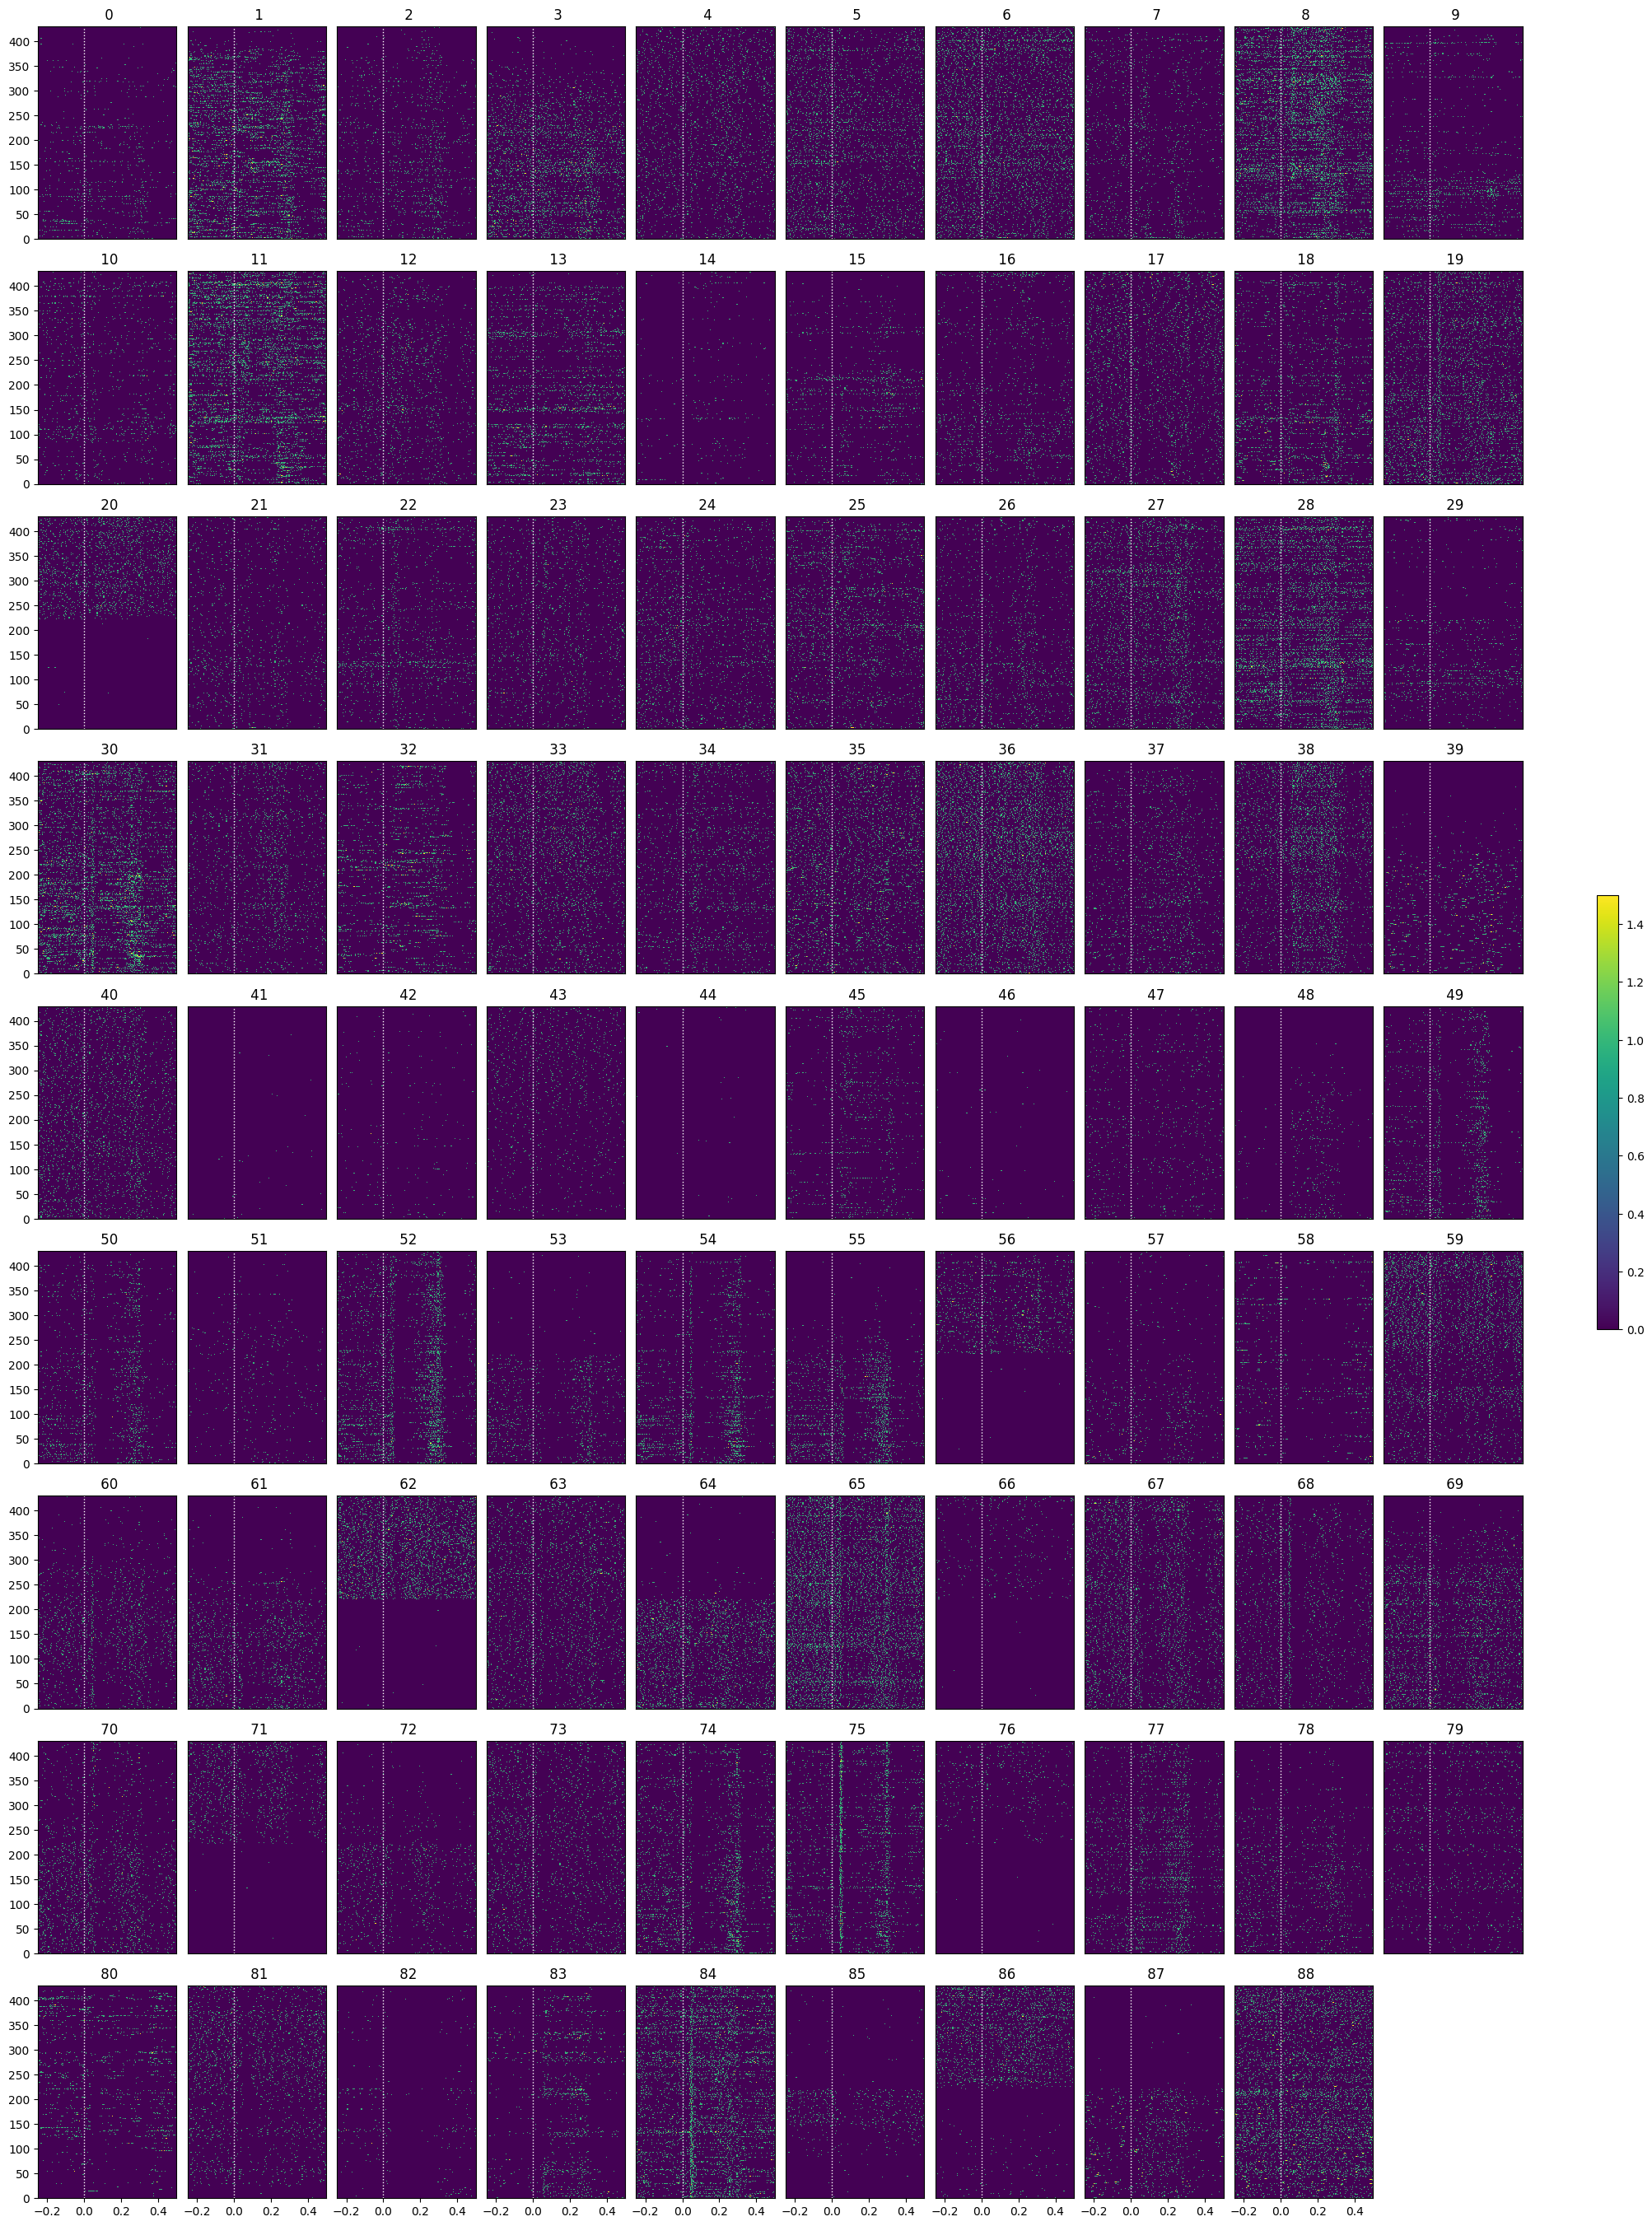

In [27]:
show_many_responses(spike_matrix_saline, 10, 10)

### Selecting Responsive Cells
As discussed in [Statistically Testing 2P Responses to Stimulus](../first-order/test_2p_responses.ipynb), the criteria used to select for responsive cells can have a significant impact. Here, the simple criterion is to select units whose post-stimulus z-scores are greater than 1 or less than -1.

In [28]:
def select_cells(spike_matrix, stimulus_onset_idx):
    baseline_means = np.mean(spike_matrix[:,:,:stimulus_onset_idx], axis=2)
    mean_baseline_means = np.mean(baseline_means, axis=1)
    std_baseline_means = np.std(baseline_means, axis=1)

    response_means = np.mean(spike_matrix[:,:,stimulus_onset_idx:], axis=2)
    mean_response_means = np.mean(response_means, axis=1)

    unit_z_scores = (mean_response_means - mean_baseline_means) / std_baseline_means
    return np.where(np.logical_or(unit_z_scores > .25, unit_z_scores < -.25))[0]

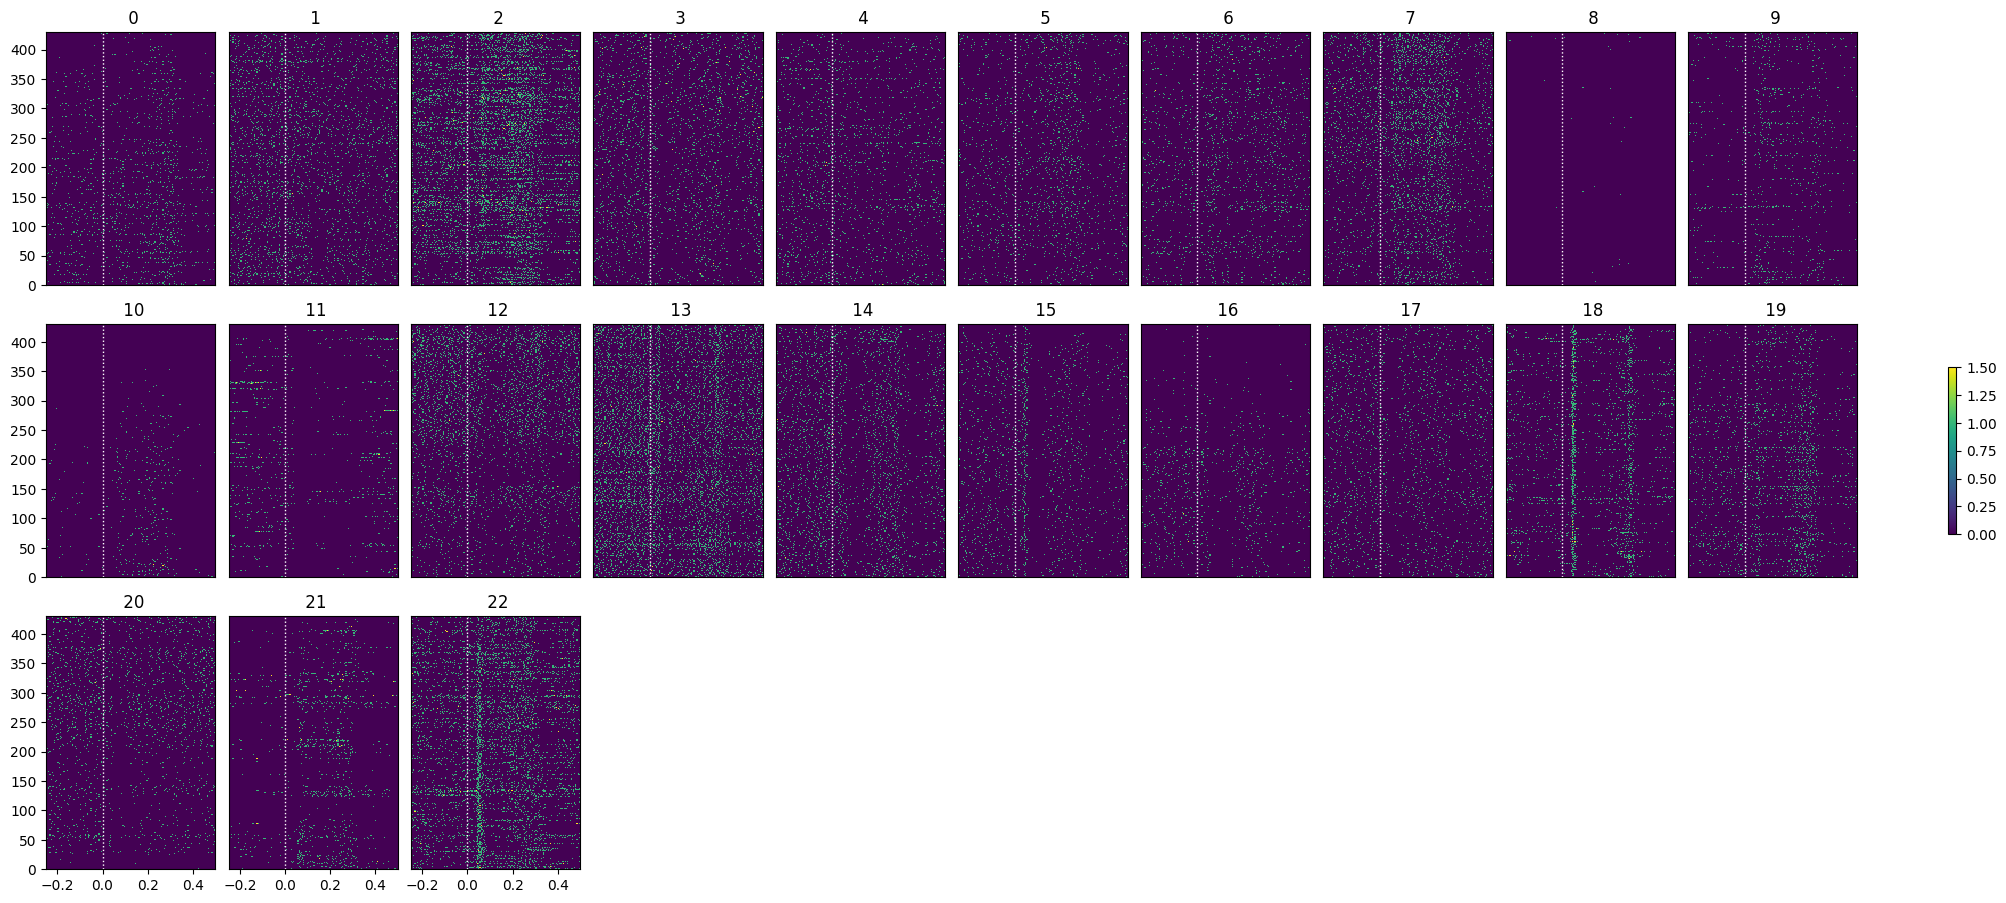

In [29]:
saline_selected_idxs = select_cells(spike_matrix_saline, stimulus_onset_idx)
show_many_responses(spike_matrix_saline[saline_selected_idxs], 5, 10)

### Comparing to Psilocybin Session

In [30]:
units_psilo = nwb_psilo.units.to_dataframe()

locations = [get_unit_location(row) for _, row in units_psilo.iterrows()]
units_spike_times_psilo = select_units(units_psilo)

print(f"Selected {len(units_spike_times_psilo)} units")

Selected 64 units


In [31]:
injection_time = nwb_saline.intervals["injection_times"].to_dataframe()["start_time"].iloc[0]
print("Injection time:", injection_time)

Injection time: 2881.3192


In [32]:
stim_table_psilo = nwb_psilo.intervals["behavior_presentations"]
selected_stim_times_psilo = [stim_table_psilo[i].start_time.item() for i in range(len(stim_table_psilo)) if stim_table_psilo.image_name[i] == "im036_r"]

print(f"Selected {len(selected_stim_times_psilo)} stimulus trials")

Selected 470 stimulus trials


In [33]:
# time bins used
n_bins = int((window_end_time - window_start_time) / time_resolution)
bin_edges = np.linspace(window_start_time, window_end_time, n_bins, endpoint=True)

# calculate baseline and stimulus interval indices for use later
stimulus_onset_idx = int(-bin_edges[0] / time_resolution)

spike_matrix_psilo = get_spike_matrix(selected_stim_times_psilo, units_spike_times_psilo, bin_edges)

print(spike_matrix_psilo.shape)

(64, 470, 149)


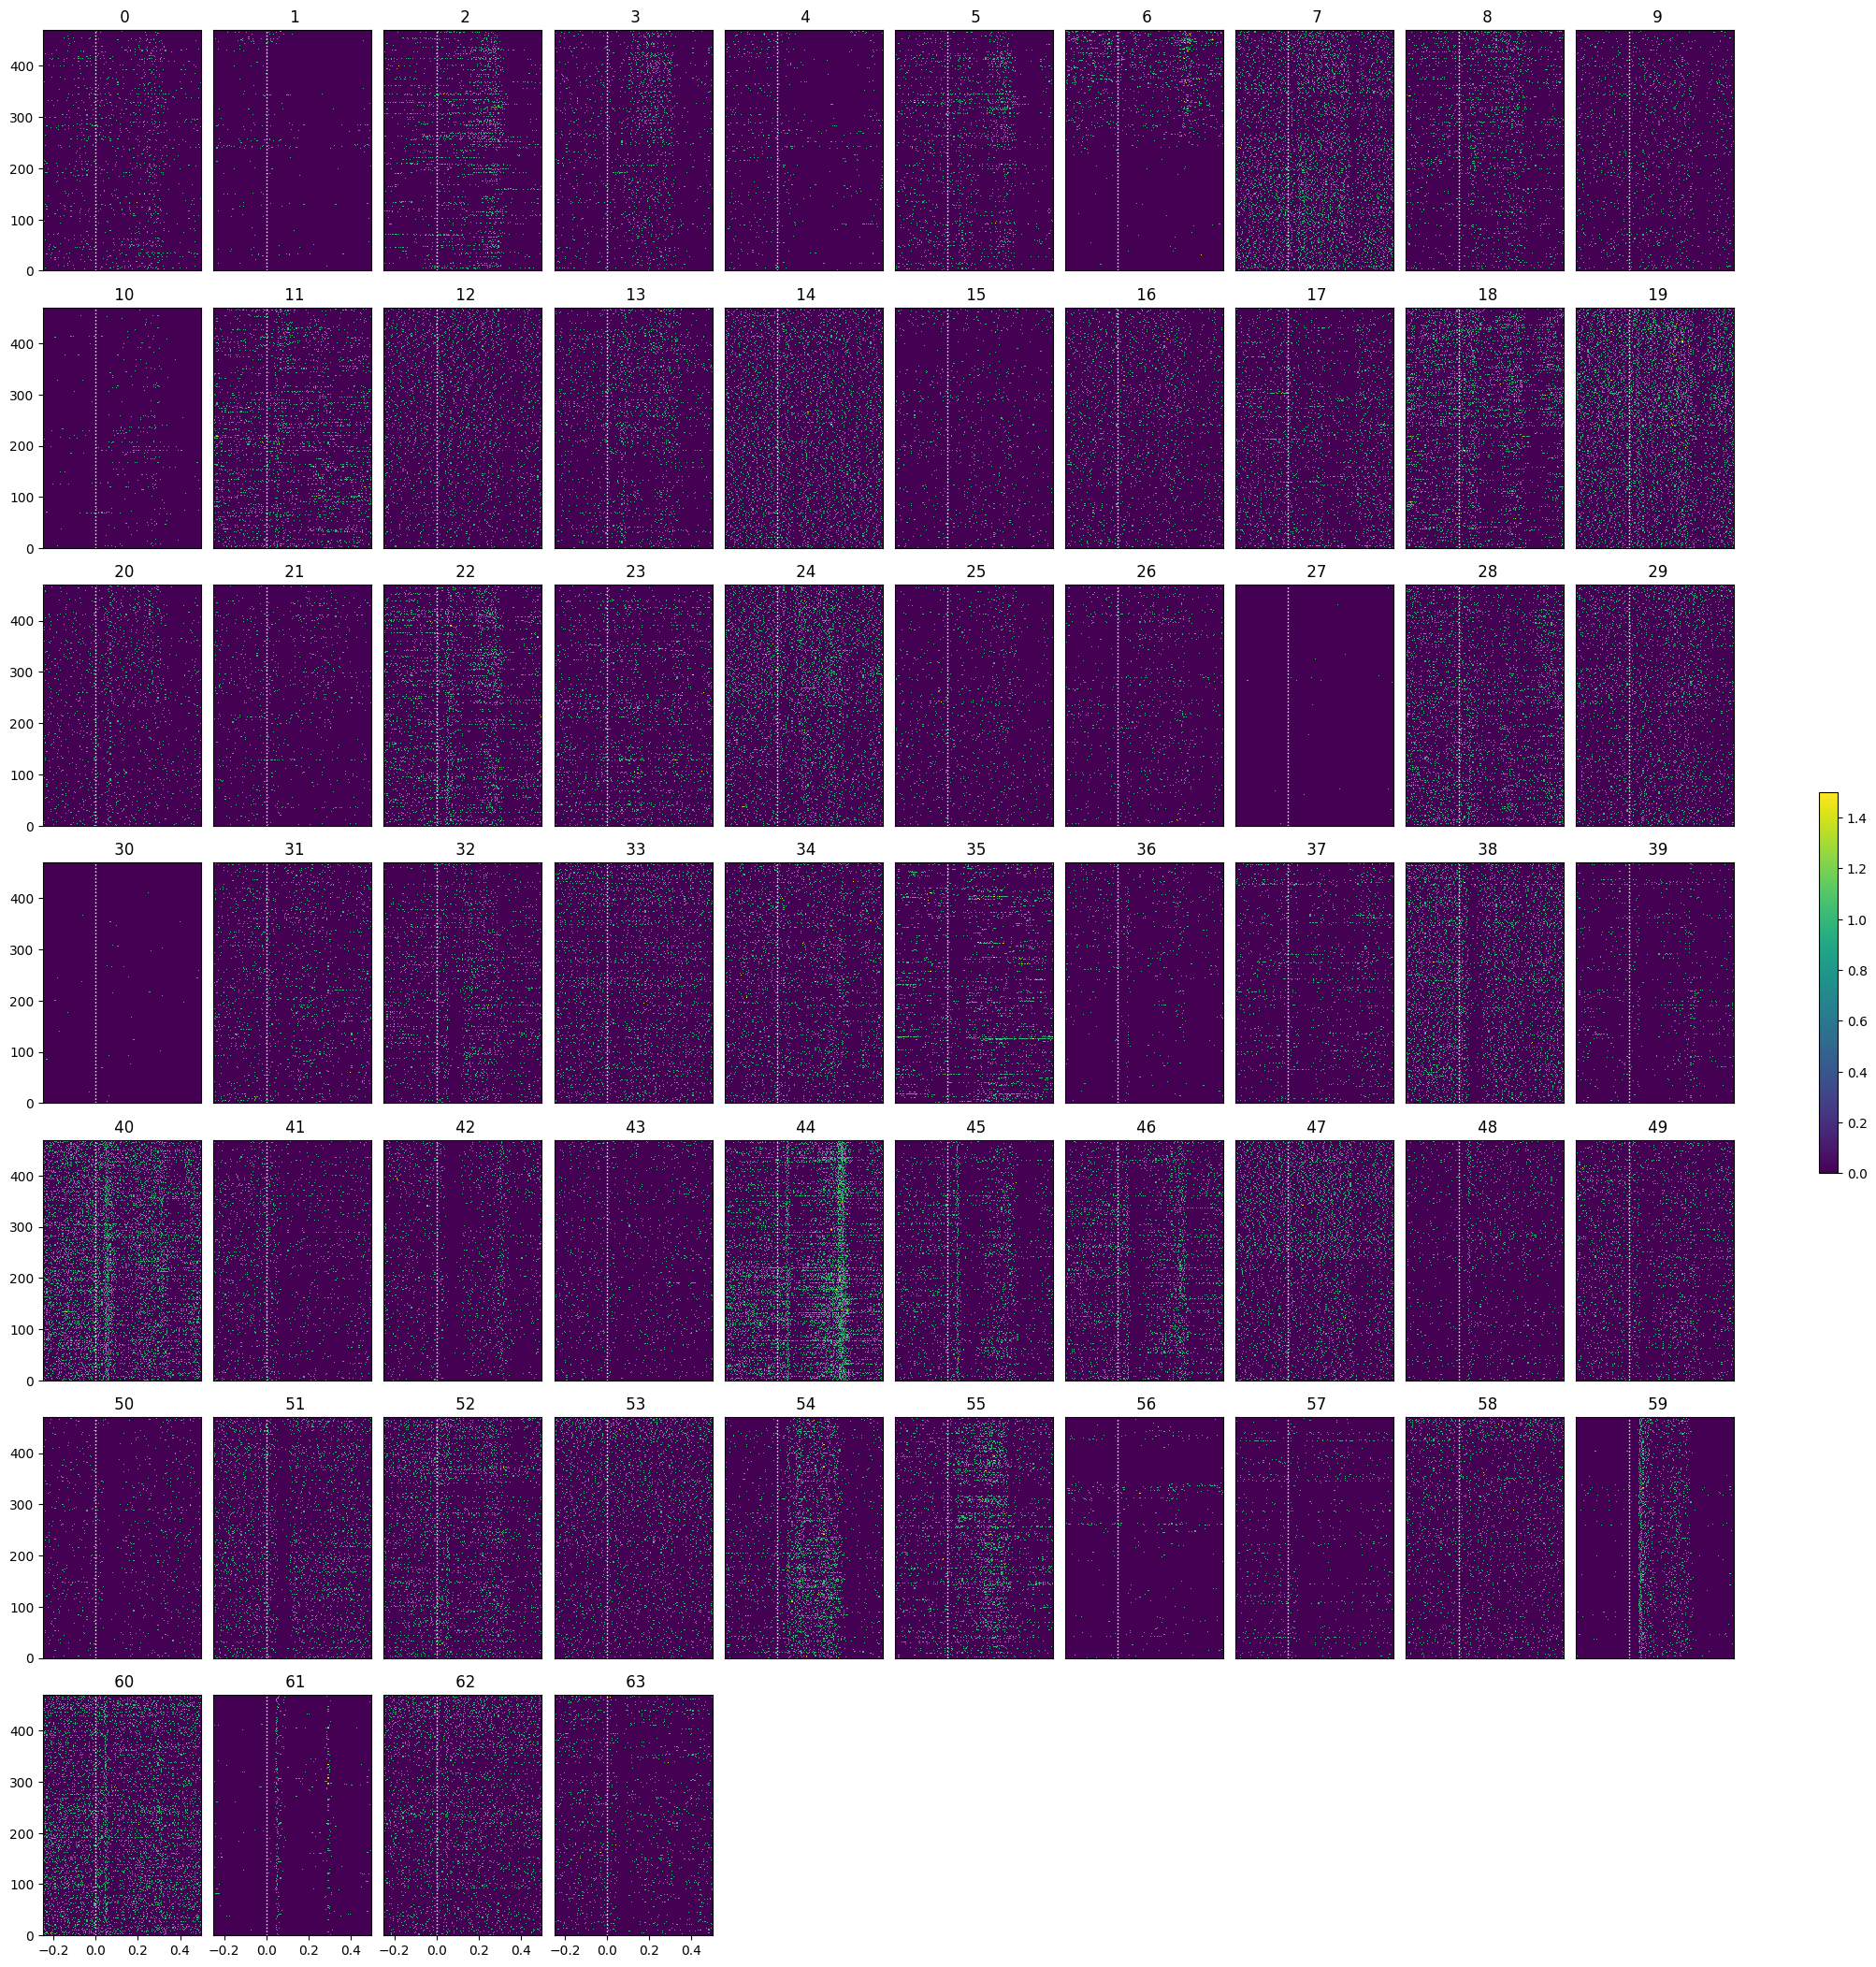

In [34]:
show_many_responses(spike_matrix_psilo, 10, 10)

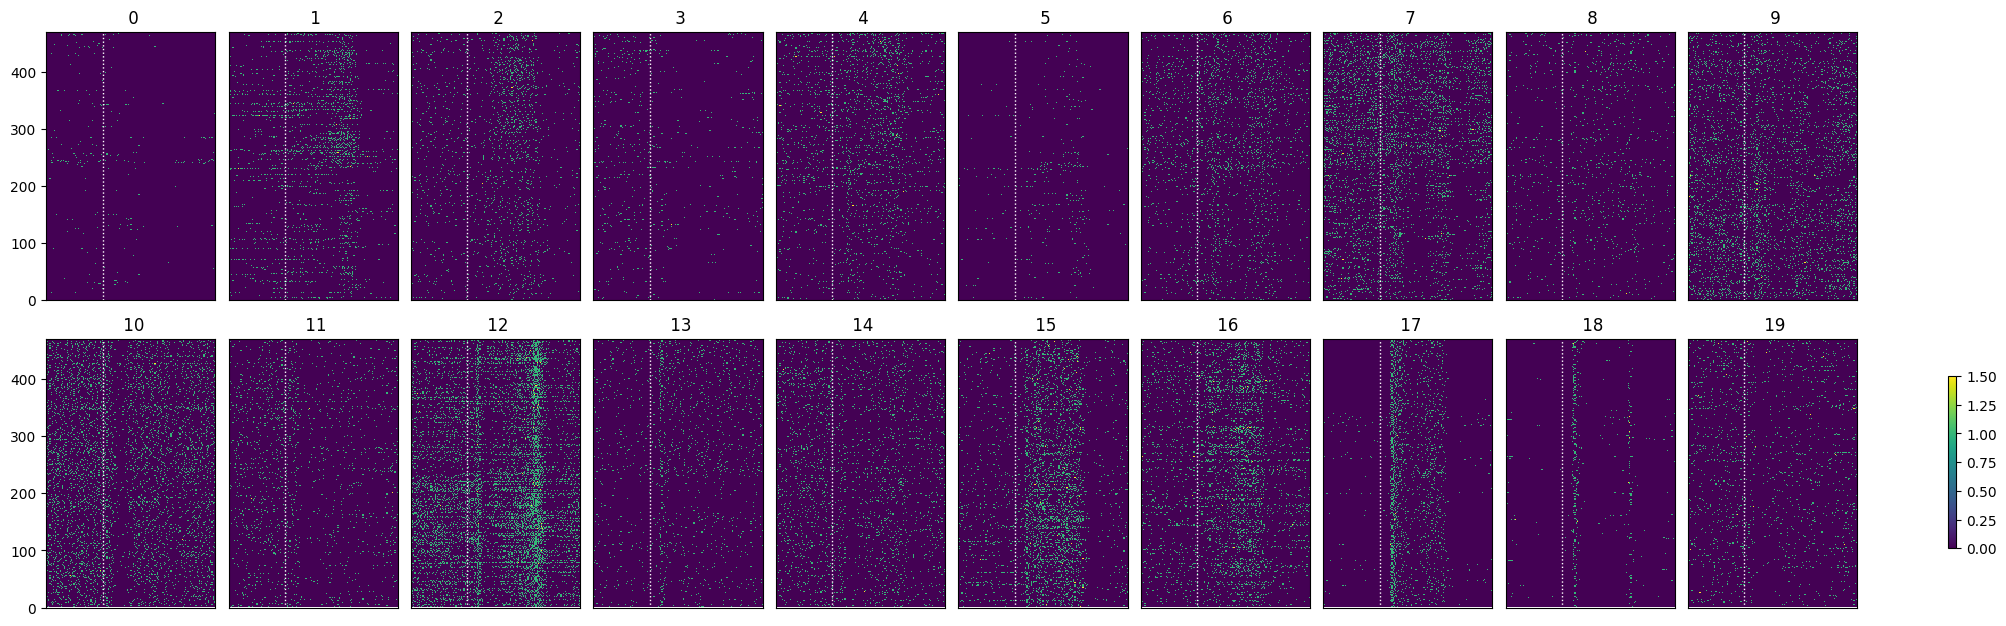

In [35]:
psilo_selected_idxs = select_cells(spike_matrix_psilo, stimulus_onset_idx)
show_many_responses(spike_matrix_psilo[psilo_selected_idxs], 5, 10)

### Optotagging
As mentioned earlier, the final epoch of the sessions is optotagging. The principles behind the optotagging are discussed in the [Identifying Optotagged Units](../first-order/optotagging.ipynb) notebook. Here you can see both activated and inhibited cells, widespread inhibition is expected because we are activating a major interneuron class: SSTs

In [36]:
opto_stim_table = nwb_saline.intervals["40 hz pulse train_presentations"]
opto_stim_table[:20]

,start_time,stop_time,condition_num,level,condition,stim_name,duration,timeseries
id,,,,,,,,
0,6452.19863,6453.19863,5,1.7,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
1,6465.97084,6466.97084,5,1.7,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
2,6468.06069,6469.06069,5,1.94,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
3,6470.14057,6471.14057,5,2.05,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
4,6474.40055,6475.40055,5,2.05,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
5,6476.49077,6477.49077,5,1.7,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
6,6492.14637,6493.14637,5,2.05,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
7,6505.56062,6506.56062,5,2.05,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."
8,6507.55072,6508.55072,5,1.7,Each pulse is 6 ms wide,40 hz pulse train,1.0,"[(14085, 0, timestamps pynwb.base.TimeSeries a..."


In [37]:
opto_stim_times = [row.start_time.item() for row in opto_stim_table if isclose(float(row.duration.item()), 1.0)]
len(opto_stim_times)
len(units_spike_times_saline)

89

In [38]:
# bin size for counting spikes
time_resolution = 0.005

# start and end times (relative to the stimulus at 0 seconds) that we want to examine and align spikes to
window_start_time = -0.25
window_end_time = 0.5

In [39]:
# time bins used
n_bins = int((window_end_time - window_start_time) / time_resolution)
bin_edges = np.linspace(window_start_time, window_end_time, n_bins, endpoint=True)

# calculate baseline and stimulus interval indices for use later
stimulus_onset_idx = int(-bin_edges[0] / time_resolution)

opto_spike_matrix = get_spike_matrix(opto_stim_times, units_spike_times_saline, bin_edges)

print(opto_spike_matrix.shape)

(89, 33, 149)


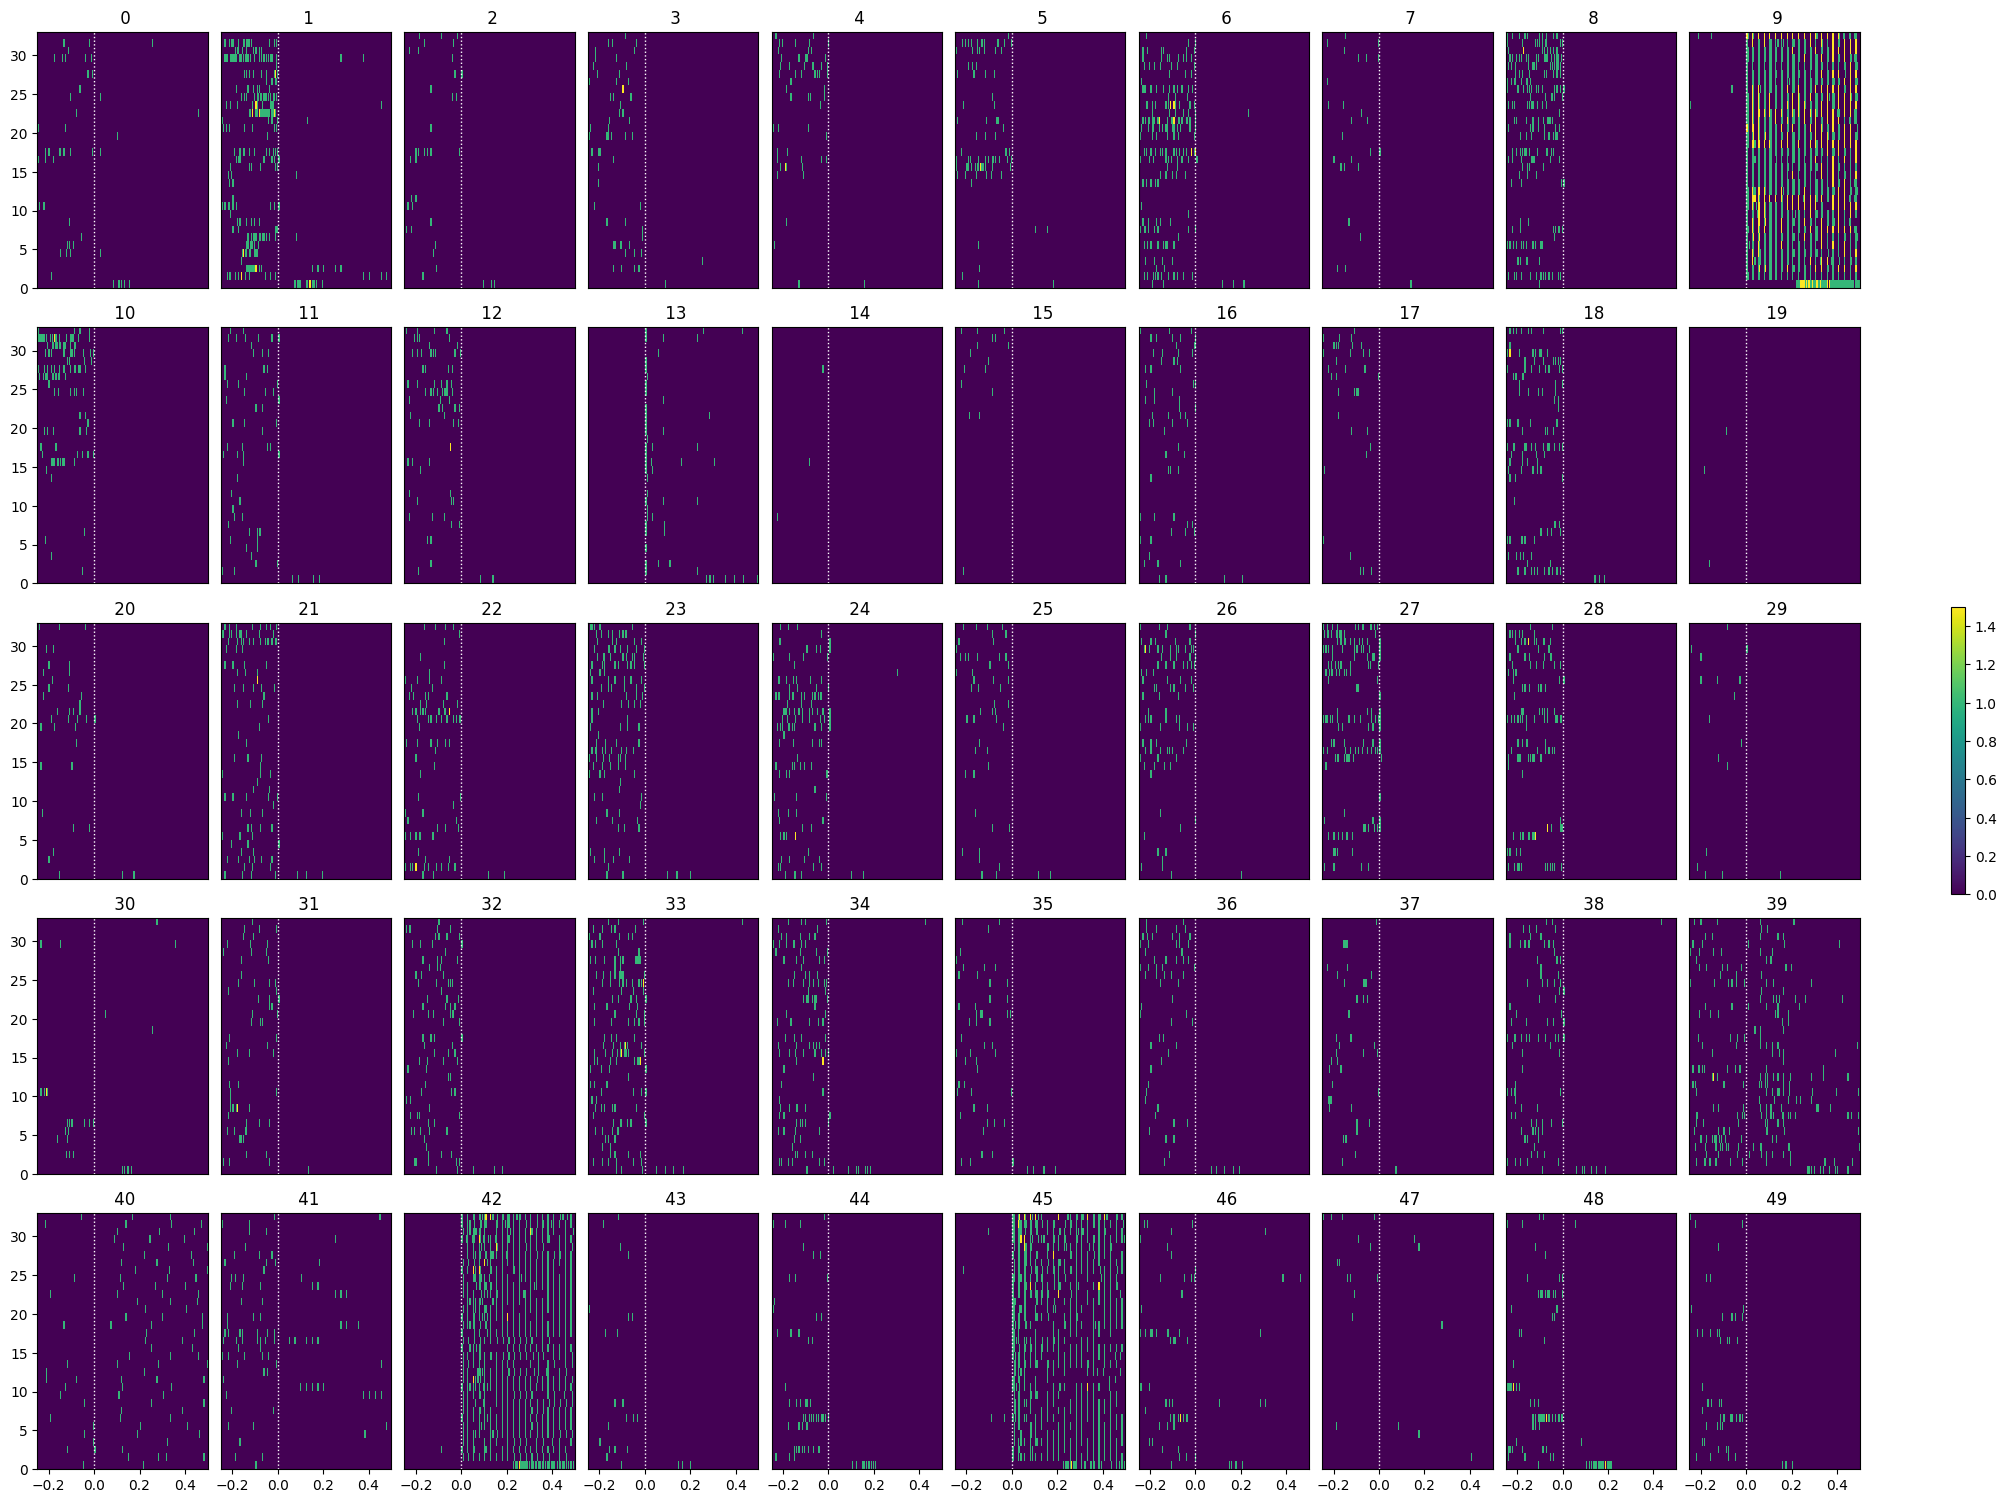

In [40]:
opto_selected_idxs = select_cells(opto_spike_matrix, stimulus_onset_idx)
show_many_responses(opto_spike_matrix[opto_selected_idxs], 5, 10)